In [5]:
import pandas as pd
import numpy as np
import os

In [6]:
data = pd.read_csv("C:\\Users\\subra\\OneDrive\\Desktop\\predict-pizza\\pizza_v2.csv")
data

,company,price_cad,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
0,A,$29,22 inch,chicken,double_signature,jumbo,yes,yes,no
1,A,$25,20 inch,papperoni,double_signature,jumbo,yes,yes,no
2,A,$19,16 inch,mushrooms,double_signature,reguler,yes,yes,yes
3,A,$22,14 inch,smoked_beef,double_signature,reguler,yes,no,yes
4,A,$30,18 inch,mozzarella,double_signature,jumbo,yes,no,yes
...,...,...,...,...,...,...,...,...,...
124,E,$11,8.5 inch,tuna,spicy tuna,small,yes,yes,yes
125,E,$14,12 inch,tuna,spicy tuna,medium,yes,yes,yes
126,E,$17,14 inch,tuna,spicy tuna,large,yes,yes,yes
127,E,$12,8.5 inch,meat,BBQ_meat_fiesta,small,yes,no,yes


In [7]:
data.columns

Index(['company', 'price_cad', 'diameter', 'topping', 'variant', 'size',
       'extra_sauce', 'extra_cheese', 'extra_mushrooms'],
      dtype='object')

In [8]:
data.describe()

,company,price_cad,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
count,129,129,129,129,129,129,129,129,129
unique,5,17,12,12,20,6,2,2,2
top,C,$14,12 inch,chicken,classic,medium,yes,yes,yes
freq,30,18,49,29,30,41,76,86,72


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   company          129 non-null    object
 1   price_cad        129 non-null    object
 2   diameter         129 non-null    object
 3   topping          129 non-null    object
 4   variant          129 non-null    object
 5   size             129 non-null    object
 6   extra_sauce      129 non-null    object
 7   extra_cheese     129 non-null    object
 8   extra_mushrooms  129 non-null    object
dtypes: object(9)
memory usage: 9.2+ KB


In [10]:
data.isnull().sum()

company            0
price_cad          0
diameter           0
topping            0
variant            0
size               0
extra_sauce        0
extra_cheese       0
extra_mushrooms    0
dtype: int64

In [11]:
data.isna().sum()

company            0
price_cad          0
diameter           0
topping            0
variant            0
size               0
extra_sauce        0
extra_cheese       0
extra_mushrooms    0
dtype: int64

In [12]:
data['company'].value_counts()

company
C    30
E    30
A    25
B    24
D    20
Name: count, dtype: int64

In [13]:
data['price_cad'].value_counts()

price_cad
$14     18
$16     17
$15     16
$12     16
$11     13
$18     11
$17      9
$19      5
$21      4
$13      4
$10      4
$20      4
$25      3
$28      2
$29      1
$22      1
$30      1
Name: count, dtype: int64

In [14]:
data['diameter'].value_counts()

diameter
12 inch      49
14 inch      23
8.5 inch     22
17 inch      10
18.5 inch     6
16 inch       5
16.5 inch     4
8 inch        4
22 inch       3
20 inch       1
18 inch       1
14 inch\n     1
Name: count, dtype: int64

In [15]:
data['topping'].value_counts()

topping
chicken         29
mushrooms       22
mozzarella      21
smoked_beef     19
vegetables       9
tuna             9
meat             8
black_papper     3
beef             3
sausage          3
papperoni        2
onion            1
Name: count, dtype: int64

In [16]:
data['variant'].value_counts()

variant
classic              30
meat_lovers          10
double_mix           10
crunchy              10
new_york             10
double_decker         9
double_signature      5
american_favorite     5
super_supreme         5
BBQ_meat_fiesta       5
spicy_tuna            3
BBQ_sausage           3
extravaganza          3
meat_eater            3
gournet_greek         3
italian_veggie        3
thai_veggie           3
american_classic      3
neptune_tuna          3
spicy tuna            3
Name: count, dtype: int64

In [17]:
data['size'].value_counts()

size
medium     41
small      22
large      21
reguler    20
jumbo      15
XL         10
Name: count, dtype: int64

In [18]:
data['extra_sauce'].value_counts()

extra_sauce
yes    76
no     53
Name: count, dtype: int64

In [19]:
data['extra_cheese'].value_counts()

extra_cheese
yes    86
no     43
Name: count, dtype: int64

In [20]:
data['extra_mushrooms'].value_counts()

extra_mushrooms
yes    72
no     57
Name: count, dtype: int64

In [21]:
data.rename({"price_cad":"price"},axis = 1, inplace=True)
data

,company,price,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
0,A,$29,22 inch,chicken,double_signature,jumbo,yes,yes,no
1,A,$25,20 inch,papperoni,double_signature,jumbo,yes,yes,no
2,A,$19,16 inch,mushrooms,double_signature,reguler,yes,yes,yes
3,A,$22,14 inch,smoked_beef,double_signature,reguler,yes,no,yes
4,A,$30,18 inch,mozzarella,double_signature,jumbo,yes,no,yes
...,...,...,...,...,...,...,...,...,...
124,E,$11,8.5 inch,tuna,spicy tuna,small,yes,yes,yes
125,E,$14,12 inch,tuna,spicy tuna,medium,yes,yes,yes
126,E,$17,14 inch,tuna,spicy tuna,large,yes,yes,yes
127,E,$12,8.5 inch,meat,BBQ_meat_fiesta,small,yes,no,yes


In [22]:
data['diameter'] = data['diameter'].str.replace("inch\n","")
data['diameter'] = data['diameter'].str.replace("inch","")
data['topping'] = data['topping'].str.replace("papperoni","Pepperoni")
data['size'] = data['size'].str.replace('reguler',"regular")
data['price'] = data['price'].str.replace("$","")

In [23]:
data

,company,price,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
0,A,29,22,chicken,double_signature,jumbo,yes,yes,no
1,A,25,20,Pepperoni,double_signature,jumbo,yes,yes,no
2,A,19,16,mushrooms,double_signature,regular,yes,yes,yes
3,A,22,14,smoked_beef,double_signature,regular,yes,no,yes
4,A,30,18,mozzarella,double_signature,jumbo,yes,no,yes
...,...,...,...,...,...,...,...,...,...
124,E,11,8.5,tuna,spicy tuna,small,yes,yes,yes
125,E,14,12,tuna,spicy tuna,medium,yes,yes,yes
126,E,17,14,tuna,spicy tuna,large,yes,yes,yes
127,E,12,8.5,meat,BBQ_meat_fiesta,small,yes,no,yes


In [24]:
data[['extra_sauce', 'extra_cheese', 'extra_mushrooms']] = data[['extra_sauce', 'extra_cheese', 'extra_mushrooms']].astype(bool)
data[['price']] = data[['price']].astype(int)
data[['diameter']] = data[['diameter']].astype(float)
data.dtypes

company             object
price                int64
diameter           float64
topping             object
variant             object
size                object
extra_sauce           bool
extra_cheese          bool
extra_mushrooms       bool
dtype: object

In [25]:
data

,company,price,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
0,A,29,22.0,chicken,double_signature,jumbo,True,True,True
1,A,25,20.0,Pepperoni,double_signature,jumbo,True,True,True
2,A,19,16.0,mushrooms,double_signature,regular,True,True,True
3,A,22,14.0,smoked_beef,double_signature,regular,True,True,True
4,A,30,18.0,mozzarella,double_signature,jumbo,True,True,True
...,...,...,...,...,...,...,...,...,...
124,E,11,8.5,tuna,spicy tuna,small,True,True,True
125,E,14,12.0,tuna,spicy tuna,medium,True,True,True
126,E,17,14.0,tuna,spicy tuna,large,True,True,True
127,E,12,8.5,meat,BBQ_meat_fiesta,small,True,True,True


company
C    30
E    30
A    25
B    24
D    20
Name: count, dtype: int64


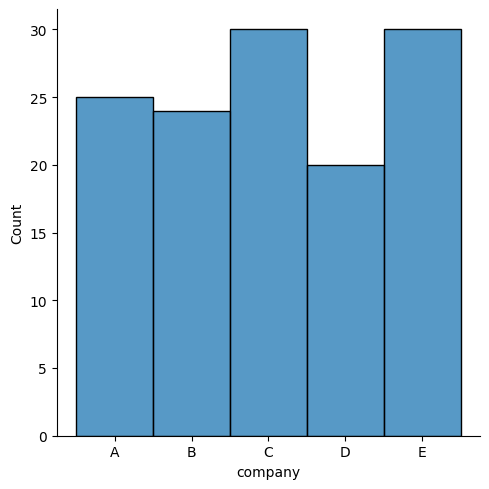

In [26]:
import seaborn as sns
print(data['company'].value_counts())
sns.displot(data['company'])

price
14    18
16    17
15    16
12    16
11    13
18    11
17     9
19     5
21     4
13     4
10     4
20     4
25     3
28     2
29     1
22     1
30     1
Name: count, dtype: int64


<Axes: xlabel='price'>

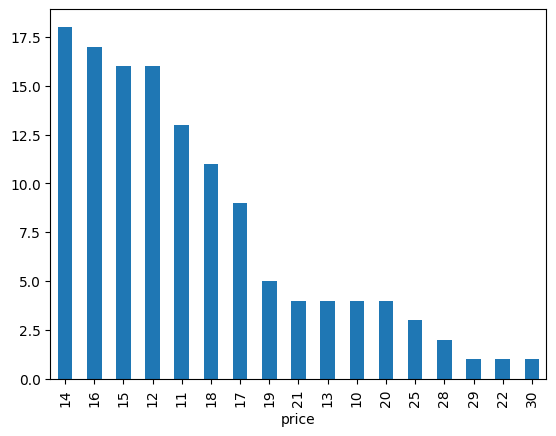

In [27]:
print(data['price'].value_counts())
data['price'].value_counts().plot.bar()

diameter
12.0    49
14.0    24
8.5     22
17.0    10
18.5     6
16.0     5
8.0      4
16.5     4
22.0     3
20.0     1
18.0     1
Name: count, dtype: int64


<Axes: xlabel='diameter'>

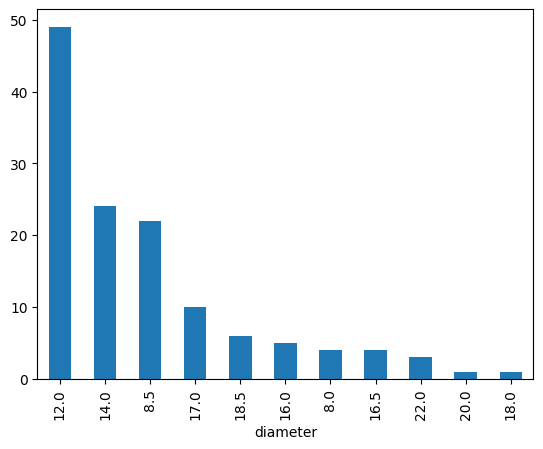

In [28]:
print(data['diameter'].value_counts())
data['diameter'].value_counts().plot.bar()

<Axes: xlabel='count', ylabel='topping'>

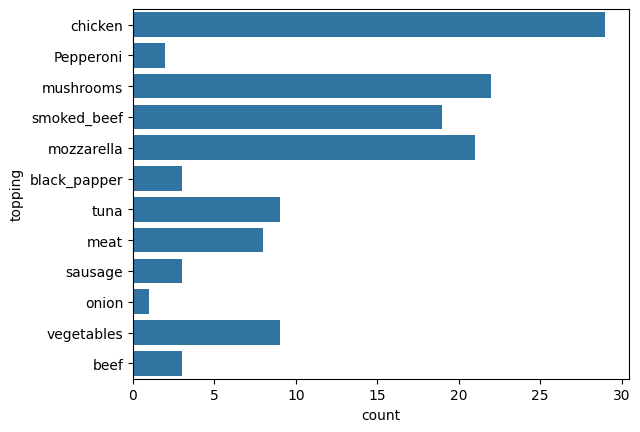

In [29]:
sns.countplot(y=data['topping'])

<Axes: xlabel='count', ylabel='variant'>

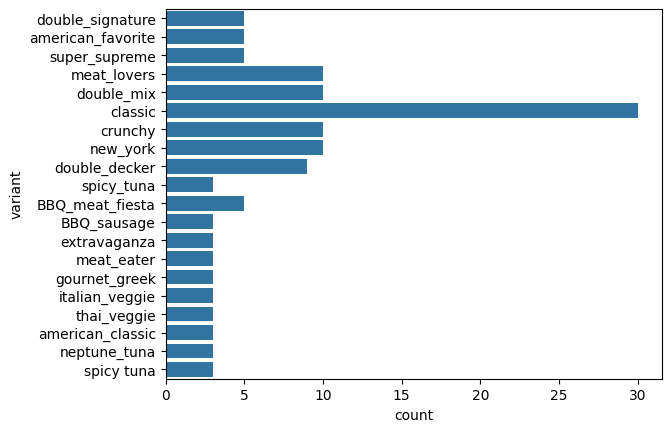

In [30]:
sns.countplot(y=data['variant'])

<Axes: xlabel='count', ylabel='size'>

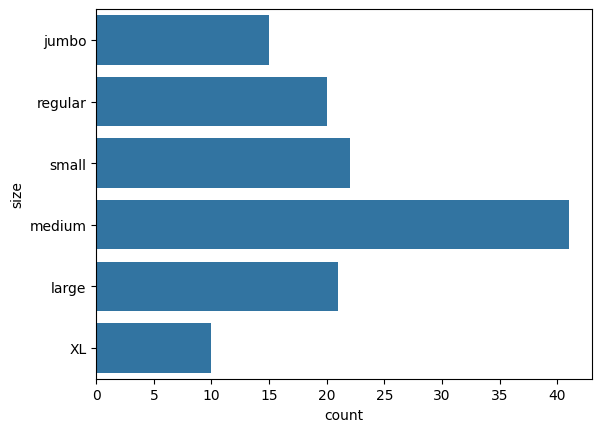

In [31]:
import seaborn as sns
sns.countplot(y=data['size'])

In [32]:
from sklearn.preprocessing import LabelEncoder
categorical_cols = data.select_dtypes(include=['object','bool']).columns
categorical_cols

Index(['company', 'topping', 'variant', 'size', 'extra_sauce', 'extra_cheese',
       'extra_mushrooms'],
      dtype='object')

In [33]:
en = LabelEncoder()
for i in categorical_cols:
    data[i] = en.fit_transform(data[i])

In [34]:
data.head()

,company,price,diameter,topping,variant,size,extra_sauce,extra_cheese,extra_mushrooms
0,0,29,22.0,3,8,1,0,0,0
1,0,25,20.0,0,8,1,0,0,0
2,0,19,16.0,6,8,4,0,0,0
3,0,22,14.0,9,8,4,0,0,0
4,0,30,18.0,5,8,1,0,0,0


In [35]:
X = data[['company','diameter','topping','variant','size','extra_sauce','extra_cheese','extra_mushrooms']]
Y = data['price']
print("Features:", X[:2])
print("Label: ", Y[:3])

Features:    company  diameter  topping  variant  size  extra_sauce  extra_cheese  \
0        0      22.0        3        8     1            0             0   
1        0      20.0        0        8     1            0             0   

   extra_mushrooms  
0                0  
1                0  
Label:  0    29
1    25
2    19
Name: price, dtype: int64


In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.35,random_state=45)

In [37]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train,Y_train)

LinearRegression()

In [38]:
reg_predict = regression.predict(X_test)

In [39]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
print(mean_squared_error(Y_test,reg_predict))
print(mean_absolute_error(Y_test,reg_predict))
print(r2_score(Y_test,reg_predict))

4.271791834626893
1.7077248350226923
0.728945918133906


In [40]:
X = data[['company','diameter','topping','variant','size','extra_sauce','extra_cheese','extra_mushrooms']]
Y = data['price']

In [41]:
lr = LinearRegression()

In [42]:
lr.fit(X,Y)

LinearRegression()

In [43]:
import joblib
joblib.dump(lr, 'Predicting_Pizza_Prize')
model = joblib.load('Predicting_Pizza_Prize')

In [44]:
df = pd.DataFrame({'company': 0,
                   'diameter': 9.5,
                   'topping': 5,
                   'variant': 7,
                   'size': 7,
                   'extra_sauce': 0,
                   'extra_cheese': 1,
                   'extra_mushrooms': 0}, 
                    index = [0])

In [45]:
model.predict(df)

array([16.07737527])

In [46]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Define bins (you can customize based on your data)
bins = [0, 30000, 60000, 90000, np.inf]
labels = [0, 1, 2, 3]  # Classes: Low, Mid, High, Very High

# Convert continuous values to classes
Y_test_binned = np.digitize(Y_test, bins) - 1
reg_predict_binned = np.digitize(reg_predict, bins) - 1

# Compute confusion matrix
cm = confusion_matrix(Y_test_binned, reg_predict_binned)
print(cm)

[[46]]


C:\Users\subra\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


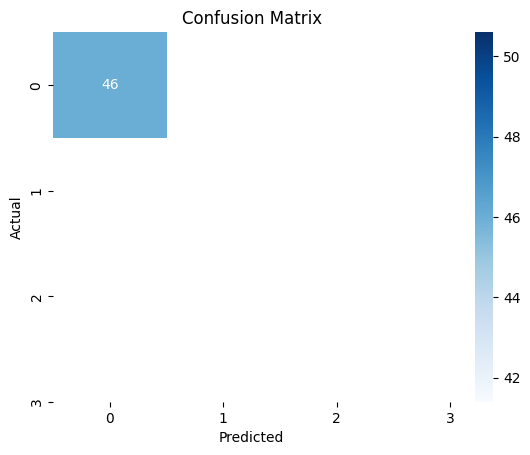

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()